* NOME: Leonardo Perim Dias
* DRE: 123294695
* E-MAIL CADASTRADO NO CLASSROOM: lperim@gmail.com

In [10]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix, roc_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, VarianceThreshold
from sklearn.decomposition import PCA
from skimage import feature, filters
import numpy as np

import seaborn as sns
from pathlib import Path
import os
import glob
import math

## **1.INTRODUÇÃO** 
O objetivo deste trabalho é desenvolver e avaliar modelos de Machine Learning capazes de identificar a presença de vulcões em imagens de satélite, de forma que a automatização do processo seja feito com o custo computacional reduzido. 
Para isso, foram testadas diferentes estratégias de pré-processamento, juntamente com o treino e a análise de diversos classificadores estudados ao longo da disciplina.

 O foco deste relatório é apresentar o processo de investigação realizado: as hipóteses formuladas, as transformações aplicadas aos dados, os modelos testados, os critérios de avaliação e os resultados obtidos. Além de buscar o melhor desempenho, o trabalho visa compreender os motivos pelos quais certos modelos funcionam melhor do que outros neste contexto de imagens de alta dimensionalidade

In [11]:
########## PRETTY MATRIX DISPLAY ##########
# Source: https://gist.github.com/braingineer/d801735dac07ff3ac4d746e1f218ab75


def matprint(mat, fmt="g", round_dig=0):
    col_maxes = [max([len(("{:"+fmt+"}").format(x))
                     for x in col]) for col in mat.T]
    for x in mat:
        for i, y in enumerate(x):
            if round_dig == 0:
                print(("{:"+str(col_maxes[i])+fmt+"}").format(y), end="  ")
            else:
                print(
                    ("{:"+str(col_maxes[i])+fmt+"}").format(round(y, round_dig)), end="  ")
        print("")
###########################################

########## CONFUSION MATRIX METRICS ##########


class ConfusionMatrixMetrics:
    def __init__(self, matrix):
        """
        Inicializa a classe com uma matriz de confusão 2x2.
        A matriz deve estar no formato:
        [[VN, FP],
         [FN, VP]]
        onde:
        - VP: Verdadeiros Positivos
        - FP: Falsos Positivos
        - FN: Falsos Negativos
        - VN: Verdadeiros Negativos
        """
        self.matrix = matrix

        self.VN = self.matrix[0][0]
        self.FP = self.matrix[0][1]
        self.FN = self.matrix[1][0]
        self.VP = self.matrix[1][1]

        self.N = self.matrix[0][0] + self.matrix[0][1]
        self.P = self.matrix[1][0] + self.matrix[1][1]

        self.Pop = self.N + self.P

    def prev(self):
        """Calcula a prevalência da classe positiva"""
        try:
            return (self.P)/(self.Pop)
        except ZeroDivisionError:
            return 0.0

    def acc(self):
        """Calcula a acurária"""
        try:
            return (self.VN + self.VP)/self.Pop
        except ZeroDivisionError:
            return 0.0

    def FPR(self):
        """Calcula a FPR"""
        try:
            return self.FP/self.N
        except ZeroDivisionError:
            return 0.0

    def TNR(self):
        """Calcula a TNR"""
        try:
            return self.VN/self.N
        except ZeroDivisionError:
            return 0.0

    def TPR(self):
        """Calcula a TPR"""
        try:
            return self.VP/self.P
        except ZeroDivisionError:
            return 0.0

    def FNR(self):
        """Calcula a FNR"""
        try:
            return self.FN/self.P
        except ZeroDivisionError:
            return 0.0

    def FOR(self):
        """Calcula a FOR"""
        try:
            return self.FN/(self.VN + self.FN)
        except ZeroDivisionError:
            return 0.0

    def PPV(self):
        """Calcula o PPV"""
        try:
            return self.VP/(self.FP + self.VP)
        except ZeroDivisionError:
            return 0.0

    def NPV(self):
        """Calcula a NPV"""
        try:
            return self.VN/(self.VN + self.FN)
        except ZeroDivisionError:
            return 0.0

    def FDR(self):
        """Calcula a FDR"""
        try:
            return self.FP/(self.FP + self.VP)
        except ZeroDivisionError:
            return 0.0

    def F1(self):
        """Calcula a F1"""
        try:
            return 2/(1/self.PPV() + 1/self.TPR())
        except ZeroDivisionError:
            return np.NaN

    def F2(self):

        try:
            beta2 = 2
            return (1 + beta2**2) * (self.PPV() * self.TPR()) / (beta2**2 * self.PPV() + self.TPR())
        except ZeroDivisionError:
            return np.NaN

    def print(self):
        """Mostra todas as métricas calculadas acima"""
        print('Matriz de confusão:')
        matprint(self.matrix)

        print('\n')

        print('Prevalência:', np.round(self.prev(), 3))
        print('Acurácia:', np.round(self.acc(), 3))

        print('\n')

        print('Taxa de falsos positivos:', np.round(self.FPR(), 3))
        print('Taxa de verdadeiros negativos (Especificidade):',
              np.round(self.TNR(), 3))
        print('Taxa de verdadeiros positivos (Recall):', np.round(self.TPR(), 3))
        print('Taxa de falsos negativos:', np.round(self.FNR(), 3))

        print('\n')

        print('False omission rate:', np.round(self.FOR(), 3))
        print('Valor preditivo positivo (Precisão):', np.round(self.PPV(), 3))
        print('Valor preditivo negativo:', np.round(self.NPV(), 3))
        print('False discovery rate:', np.round(self.FDR(), 3))

        print('\n')

        print('F1 Score:', np.round(self.F1(), 3))
        print('F2 Score:', np.round(self.F2(), 3))
    ##############################################

In [12]:
# Selecionar pasta dos dados
Pasta = r'C:\Users\Leo\Projects\Projeto 2'

Imagens1 = './train_images'
Resposta1 = './train_labels'
Imagens2 = './test_images'
Resposta2 = './test_labels'

feat = pd.read_csv(os.path.join(Pasta, 'train_images.csv'), header = None)
resp = pd.read_csv(os.path.join(Pasta, 'train_labels.csv'))
test_feat = pd.read_csv(os.path.join(Pasta, 'test_images.csv'), header = None)
test_resp = pd.read_csv(os.path.join(Pasta, 'test_labels.csv'))


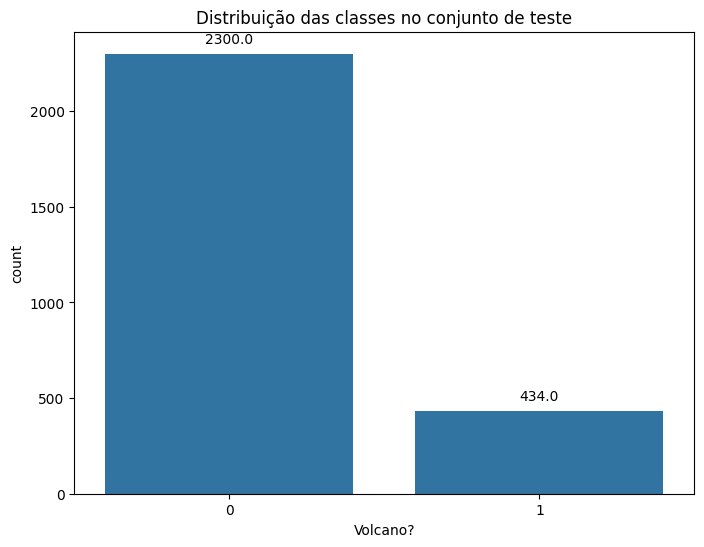

In [13]:
# Distribuição das classes no conjunto de teste
plt.figure(figsize=(8,6))
ax = sns.countplot(data=test_resp, x='Volcano?')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')

plt.title('Distribuição das classes no conjunto de teste')
plt.show()

## **2.ANALISE EXPLORÁTORIA DO DADOS** 
Em geral, as informações sobre o conjunto de treino já foram expostas na apresentação do projeto. Quanto ao conjunto de teste, ele apresenta a mesma quantidade de variaveis, menor quantidade de observações e uma distribuição de classes similar ao conjunto de treino. As imagens de ambos apresentem bastante ruido.

A análise de correlação entre os preditores revela um padrão esperado para dados de imagem que retratam revlevos: os pixels apresentam forte correlação linear com seus vizinhos imediatos, e essa correlação diminui gradualmente à medida que a distância entre os pixels aumenta. Em relação à variável resposta, observa-se que a maior parte dos preditores apresenta correlação praticamente nula com a classe, com apenas um pequeno grupo de pixels exibindo correlações fracas. 

A distribuição média das variaveis quanto as classes apresenta a mesma imagem quanto o mapa de calor da variavel de resposta. Isso sugere que, possivelmente, apenas uma fração dos pixels, especialmente os centrais, contém a maior parte da informação relevante para determinar a presença de vulcões.


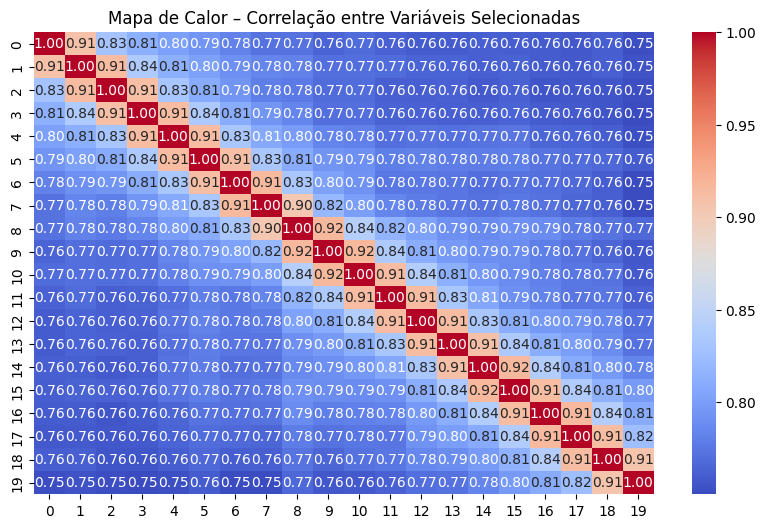

In [ ]:
# Matriz de correlação entre as 20 primeiras variáveis
cols = feat.columns[:20]

corr_matrix = feat[cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Calor – Correlação entre Variáveis Selecionadas")
plt.show()

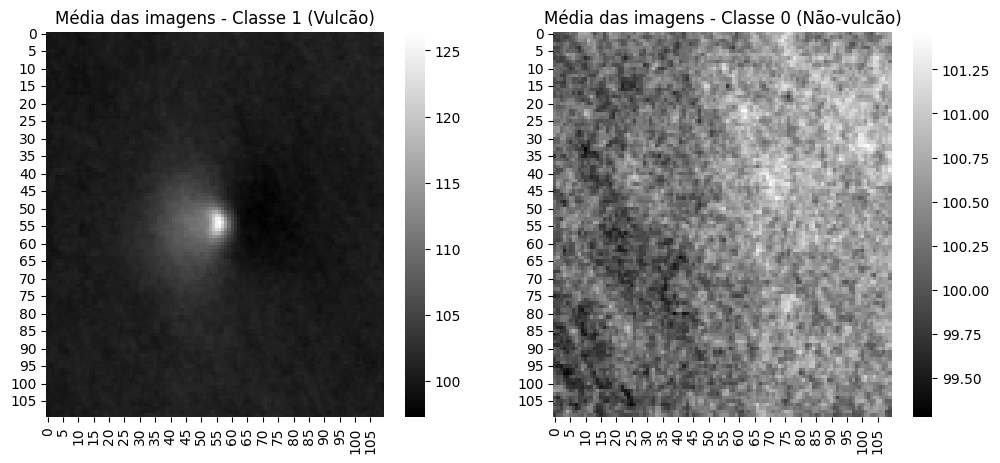

In [15]:
# Imagem media do vulcão 
img_size = int(math.sqrt(feat.shape[1]))

# Média das imagens positivas
mean_pos = feat[resp['Volcano?'] == 1].mean().values.reshape(img_size, img_size)

# Média das imagens negativas
mean_neg = feat[resp['Volcano?'] == 0].mean().values.reshape(img_size, img_size)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(mean_pos, cmap='gray')
plt.title("Média das imagens - Classe 1 (Vulcão)")

plt.subplot(1, 2, 2)
sns.heatmap(mean_neg, cmap='gray')
plt.title("Média das imagens - Classe 0 (Não-vulcão)")

plt.show()


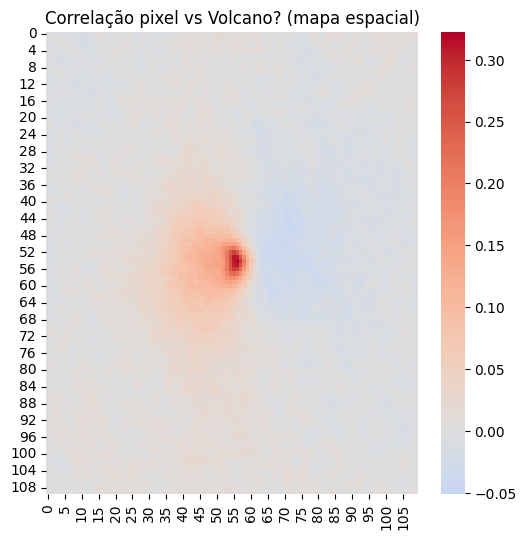

In [16]:
# Correlação pixel vs Volcano? (mapa espacial)
correlation_with_target = feat.corrwith(resp['Volcano?'])
img_size = int(math.sqrt(len(correlation_with_target)))

corr_image = correlation_with_target.values.reshape(img_size, img_size)

plt.figure(figsize=(6, 6))
sns.heatmap(corr_image, cmap='coolwarm', center=0)
plt.title("Correlação pixel vs Volcano? (mapa espacial)")
plt.show()

## **3.PRÉ-PROCESSAMENTO**
Dado o alto ruído das imagens, o pré-processamento se tornou nescessario a fim de melhorar a qualidade dos preditores e o resultado e processamento dos modelos. 

Inicialmente, foi dividido o valor das variaveis por 255.0, estabelecendo um intervalo de [0, 1], para evitar que algoritimos que são sensiveis a escala apresentem instabilidade numerica e lentidão na execução. 

Em seguida, foram aplicados os filtros **Sobel**, que destaca bordas suaves no intuito de identificar variações na textura, e **Canny** que busca encontrar bordas robustas com o objetivo de destacar regiões na imagem. Depois estes valores foram somados em um novo conjunto de dados que possui 36300 variaveis. 

Dada a alta dimensionalidade original das imagens, aplicou-se também Análise de Componentes Principais (PCA). O PCA permitiu capturar a maior parte da variância dos dados em um número significativamente menor de componentes, reduzindo o custo computacional. A escolha do número de componentes foi guiada por dois usos do GridSearchCV, permitindo identificar quantidades mais adequadas para diferentes grupos de modelos. Em modelos que se beneficiam de um maior numero de variaveis foi usado n_components = 200, enquanto em algoritimos que podem apresentar problemas de dimensionalidade foi usado n_components = 50. 


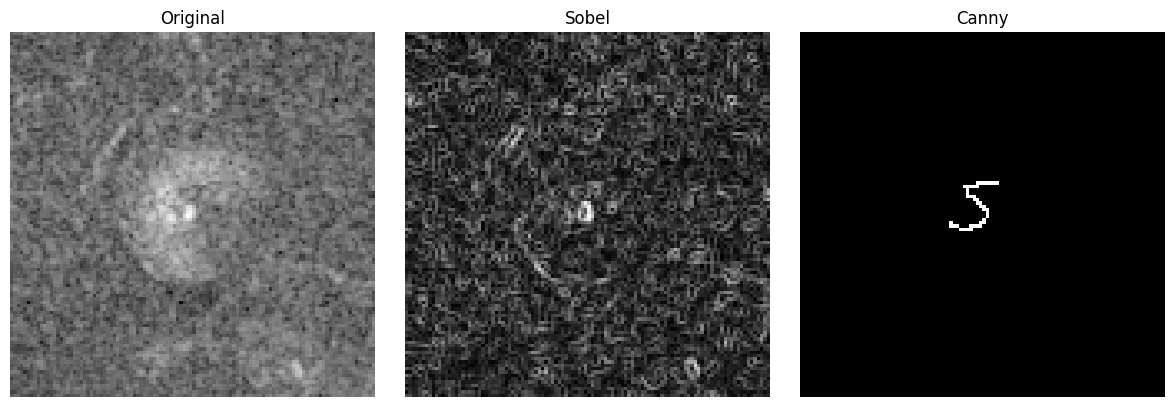

In [17]:
# Visualizar uma amostra das imagens com suas bordas
# transformar a linha em imagem 110x110
img = feat.iloc[9].values.reshape(110, 110).astype(np.float32)
img = img / 255.0

# gerar camadas
sobel = filters.sobel(img)
canny = feature.canny(img, sigma=2).astype(np.float32)

# plotar
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Sobel")
plt.imshow(sobel, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Canny")
plt.imshow(canny, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


In [18]:
# processador de imagens
def processar_imagens(df):

    processed = []
    for i in range(len(df)):
        # Converter para imagem e garantir dtype compatível (float32)
        img = df.iloc[i].values.reshape(110, 110).astype(np.float32)

        # Normaliza para [0, 1] (skimage funciona melhor com floats nessa faixa)
        img = img / 255.0

        sobel = filters.sobel(img)
        canny = feature.canny(img, sigma=2).astype(np.float32)
        multicanal = np.stack([img, sobel, canny], axis=-1)
        flattened = multicanal.flatten()
        processed.append(flattened)
    return np.array(processed, dtype=np.float32)


In [19]:
# processar as imagens de treino e teste
Pr_feat = processar_imagens(feat)
Pr_test = processar_imagens(test_feat)

## **4.TREINO DOS MODELOS**
### **4.1.Considerações gerais**
A etapa de modelagem foi conduzida de maneira sistemática. Todos os modelos foram treinados seguindo uma estrutura padronizada de pipeline, combinada com validação cruzada e otimização de hiperparâmetros.

Para todos os classificadores avaliados, foi construído um único pipeline composto por três etapas principais:


*   Standard Scaler: Embora os pixels já estivessem normalizados no intervalo 
[0,1], diversos modelos se beneficiam de dados padronizados com média zero e mesma variância
*   PCA: O uso de pca no pipeline para evitar vazamento de dados.
*   A etapa final do pipeline recebia um dos classificadores estudados em sala de aula, dessa forma, todo o processo era executado de forma integrada e coerente para cada modelo.

A escolha dos hiperparâmetros ideais para cada modelo foi realizada por meio de validação cruzada. Nos casos do "LinearSVC" e "Regression Tree" foram tambem escolhidos os valores de componentes do PCA. A escolha de não aplicar a escolha dos componentes em todos os "GridSearch" se deve ao objetivo de reduzir o custo computacional do treino de modelos. 

Como métrica do sistema, foi utilizado o F2 score, ao inves de "accuracy" ou "F1 score" como uma forma de levar em conta que o erro de falso negativo nescessita de maior penalidade. 


In [20]:
# f2 scorer
from sklearn.metrics import make_scorer, fbeta_score
f2 = make_scorer(fbeta_score, beta=2)

In [21]:
# Criando tabela comparativa de resultados
resultados = {
    'Modelo': [],
    'Acurácia': [],
    'F2 Score': [],
}

def append_results(nome, cm):
    cm_metrics = ConfusionMatrixMetrics(cm)
    resultados["Modelo"].append(nome)
    resultados["Acurácia"].append(np.round(cm_metrics.acc(), 3))
    resultados["F2 Score"].append(np.round(cm_metrics.F2(), 3))


### **4.2.SVC**



*   Kernel Linear: Teve excelente performance, e apenas apresentou alto custo computacional pois foi utilizado para determinar o valor de componentes do PCA. Sua qualidade de performance se deve a natureza linear da correlação dos dados.
*   Kernel rbf: Excelente performance, e se comportou melhor em comparação com o Kernel Linear. A capacidade de se ajustar melhor devido a sua natureza não linear. 


In [22]:
# SVC com Kernel Linear
LinearSVC = Pipeline([('Scaler', StandardScaler()),
                    ('pca', PCA()),
                    ('LSVC', LinearSVC( class_weight='balanced'))])
grid_LinearSVC = {'LSVC__C': [0.01, 0.1, 1, 5, 10],
                  'pca__n_components': [50, 100, 150, 200]}

LinearSVC_CV = GridSearchCV(LinearSVC,
                            param_grid= grid_LinearSVC,
                            cv = 5,
                            scoring= f2,
                            n_jobs=-1,
                            verbose = 1)


LinearSVC_CV.fit(Pr_feat, resp['Volcano?'])
CM_LinearSCV2 = confusion_matrix(test_resp['Volcano?'], LinearSVC_CV.predict(Pr_test))
append_results("SVC Kernel Linear", CM_LinearSCV2)
ConfusionMatrixMetrics(CM_LinearSCV2).print()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Matriz de confusão:
2136  164  
  79  355  


Prevalência: 0.159
Acurácia: 0.911


Taxa de falsos positivos: 0.071
Taxa de verdadeiros negativos (Especificidade): 0.929
Taxa de verdadeiros positivos (Recall): 0.818
Taxa de falsos negativos: 0.182


False omission rate: 0.036
Valor preditivo positivo (Precisão): 0.684
Valor preditivo negativo: 0.964
False discovery rate: 0.316


F1 Score: 0.745
F2 Score: 0.787


In [23]:
LinearSVC_CV.best_params_

{'LSVC__C': 10, 'pca__n_components': 200}

In [24]:
# SVC com kernel RBF
SVC_rbf_pipe = Pipeline([
    ('Scaler', StandardScaler()),
    ('PCA', PCA(n_components=200)),
    ('SVC', SVC(kernel='rbf', cache_size=4000))
])

# grid reduzido porém eficiente
param_grid_rbf = {
    'SVC__gamma': ['scale', 1e-3, 1e-4],
    'SVC__C': [1, 10, 50, 100],
}

SVC_rbf_CV = GridSearchCV(
    SVC_rbf_pipe,
    param_grid=param_grid_rbf,
    cv=5,
    scoring= f2,
    n_jobs=-1,
    verbose=1
)

SVC_rbf_CV.fit(Pr_feat, resp['Volcano?'])
CM_rbf_SVC = confusion_matrix(test_resp['Volcano?'], SVC_rbf_CV.predict(Pr_test))
append_results("SVC Kernel RBF", CM_rbf_SVC)
ConfusionMatrixMetrics(CM_rbf_SVC).print()

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Matriz de confusão:
2237   63  
 101  333  


Prevalência: 0.159
Acurácia: 0.94


Taxa de falsos positivos: 0.027
Taxa de verdadeiros negativos (Especificidade): 0.973
Taxa de verdadeiros positivos (Recall): 0.767
Taxa de falsos negativos: 0.233


False omission rate: 0.043
Valor preditivo positivo (Precisão): 0.841
Valor preditivo negativo: 0.957
False discovery rate: 0.159


F1 Score: 0.802
F2 Score: 0.781


### **4.3.Regressão Logistica**
Tambem teve excelente performance. Pior precisão em comparação aos modelos de SVC, porem foi capaz de identificar mais vulcões. Teve custo computacional alto em comparação a outros modelos.

In [25]:
# Logistic Regression Classifier
LR_pipe = Pipeline([('Scaler', StandardScaler()),
                    ('PCA', PCA(n_components=200)),
                    ('lr', LogisticRegression(penalty='elasticnet',
                                            class_weight='balanced',
                                            solver='saga',
                                            max_iter=500))])

param_grid_LR = {'lr__C': [0.01, 0.1, 1, 10],
                'lr__l1_ratio': [0.1, 0.5, 0.9]}

LR_pipe_CV = GridSearchCV(LR_pipe,
                        param_grid=param_grid_LR,
                        cv = 5,
                        scoring= f2,
                        n_jobs=-1,
                        verbose= 1)

LR_pipe_CV.fit(Pr_feat, resp['Volcano?'])
CM_LR_pipe = confusion_matrix(test_resp['Volcano?'], LR_pipe_CV.predict(Pr_test))
append_results("Logistic Regression", CM_LR_pipe)
ConfusionMatrixMetrics(CM_LR_pipe).print()

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\Leo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Matriz de confusão:
2108  192  
  67  367  


Prevalência: 0.159
Acurácia: 0.905


Taxa de falsos positivos: 0.083
Taxa de verdadeiros negativos (Especificidade): 0.917
Taxa de verdadeiros positivos (Recall): 0.846
Taxa de falsos negativos: 0.154


False omission rate: 0.031
Valor preditivo positivo (Precisão): 0.657
Valor preditivo negativo: 0.969
False discovery rate: 0.343


F1 Score: 0.739
F2 Score: 0.8


### **4.4.LDA**
Teve boa precisão em geral (0.907), porem foi incapaz de identificar corretamente a maior parte dos vulcões. Se beneficiou da natureza linear das variaveis, porem provavelmente foi prejudicado pelas variaveis nao seguirem uma distribuição gaussiana. Teve alto custo computacional.

In [26]:
# Linear Discriminant Analysis
LDA = Pipeline([('Scaler', StandardScaler()),
                ('PCA', PCA(n_components=200)),
                ('LDA', LinearDiscriminantAnalysis())])

param_grid_LDA = {
    'LDA__solver': ['lsqr', 'eigen'],
    'LDA__shrinkage': [0.1, 0.5, 0.9],
    'LDA__tol': [1e-4],
}

LDA_CV = GridSearchCV( LDA,
    param_grid_LDA,
    cv=5,
    scoring=f2,
    n_jobs=-1,
    verbose=1
)

LDA_CV.fit(Pr_feat,resp['Volcano?'])
CM_LDA = confusion_matrix(test_resp['Volcano?'], LDA_CV.predict(Pr_test))
append_results("LDA", CM_LDA)
ConfusionMatrixMetrics(CM_LDA).print()

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Matriz de confusão:
2273   27  
 220  214  


Prevalência: 0.159
Acurácia: 0.91


Taxa de falsos positivos: 0.012
Taxa de verdadeiros negativos (Especificidade): 0.988
Taxa de verdadeiros positivos (Recall): 0.493
Taxa de falsos negativos: 0.507


False omission rate: 0.088
Valor preditivo positivo (Precisão): 0.888
Valor preditivo negativo: 0.912
False discovery rate: 0.112


F1 Score: 0.634
F2 Score: 0.541


### **4.5.QDA**
Pessima performance em geral, teve tendencia de classificar a maior parte das imagens como contendo vulcões. A performance se deve ao possivel ruido dos dados, dimensionalidade da base de dados, e a correlação entre as variaveis. Apresentou baixo tempo de treino. 


In [27]:
# Quadratic Discriminant Analysis
QDA_pipe = Pipeline([('Scaler', StandardScaler()),
                     ('PCA', PCA(n_components=200)),
                     ('QDA', QuadraticDiscriminantAnalysis())])
param_grid_QDA = {
    'QDA__reg_param': [0.0, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
}

QDA_pipe_CV = GridSearchCV(
    QDA_pipe,
    param_grid= param_grid_QDA,
    cv=5,
    scoring= f2,
    n_jobs=-1,
    verbose=1
)

QDA_pipe_CV.fit(Pr_feat, resp['Volcano?'])
CM_QDA = confusion_matrix(test_resp['Volcano?'], QDA_pipe_CV.predict(Pr_test))
append_results("QDA", CM_QDA)
ConfusionMatrixMetrics(CM_QDA).print()

Fitting 5 folds for each of 8 candidates, totalling 40 fits


Matriz de confusão:
902  1398  
 88   346  


Prevalência: 0.159
Acurácia: 0.456


Taxa de falsos positivos: 0.608
Taxa de verdadeiros negativos (Especificidade): 0.392
Taxa de verdadeiros positivos (Recall): 0.797
Taxa de falsos negativos: 0.203


False omission rate: 0.089
Valor preditivo positivo (Precisão): 0.198
Valor preditivo negativo: 0.911
False discovery rate: 0.802


F1 Score: 0.318
F2 Score: 0.497


### **4.6.Arvore de regressão**
Utilizada para definir os componentes do PCA de modelos que sofrem com problema de dimensionalidade. Teve uma precisao boa, porem classificou errado mais da metade dos vulcões, apresentou resultados inferiores aos modelos lineares, com alto custo computacional devido ao ajuste de componentes.

In [28]:
# Decision Tree Classifier
DT_pipe = Pipeline([('PCA', PCA()),
                    ('DT', DecisionTreeClassifier(min_samples_leaf = 5,class_weight='balanced'))])

param_grid_DT = {
    'DT__criterion': ['gini', 'entropy'],
    'DT__ccp_alpha': np.logspace(-10, -5, 10),
    'PCA__n_components': [20, 50, 100, 150]}

DT_pipe_CV = GridSearchCV(DT_pipe, 
                          param_grid = param_grid_DT, 
                          cv=5,
                          scoring= f2, 
                          n_jobs=-1)

DT_pipe_CV.fit(Pr_feat, resp['Volcano?'])
CM_DT_pipe = confusion_matrix(test_resp['Volcano?'], DT_pipe_CV.predict(Pr_test))
append_results("Decision Tree", CM_DT_pipe)
ConfusionMatrixMetrics(CM_DT_pipe).print()

Matriz de confusão:
2021  279  
 168  266  


Prevalência: 0.159
Acurácia: 0.837


Taxa de falsos positivos: 0.121
Taxa de verdadeiros negativos (Especificidade): 0.879
Taxa de verdadeiros positivos (Recall): 0.613
Taxa de falsos negativos: 0.387


False omission rate: 0.077
Valor preditivo positivo (Precisão): 0.488
Valor preditivo negativo: 0.923
False discovery rate: 0.512


F1 Score: 0.543
F2 Score: 0.583


In [29]:
DT_pipe_CV.best_params_

{'DT__ccp_alpha': np.float64(4.641588833612773e-09),
 'DT__criterion': 'gini',
 'PCA__n_components': 20}

### **4.7.Arvores Aleatorias**
Mais robusto que a árvore isolada, mas ainda assim não alcançou o desempenho dos SVC e do LDA. Não capturaram bem estruturas contínuas e sutis presentes nas imagens, tendo uma excelente performance quando classificando imagens sem montanhas porem tendo alto erro com falsos negativos.

In [30]:
# Random Forest Classifier
RF_pipe = Pipeline([('Scaler', StandardScaler()),
                    ('PCA', PCA(n_components=50)),
                    ('RF', RandomForestClassifier(n_estimators = 5000,
                                                  criterion = 'entropy'))])

RF_pipe.fit(Pr_feat, resp['Volcano?'])
CM_RF_pipe = confusion_matrix(test_resp['Volcano?'], RF_pipe.predict(Pr_test))   
append_results("Random Forest", CM_RF_pipe)
confusion_matrix_metrics = ConfusionMatrixMetrics(CM_RF_pipe).print()

Matriz de confusão:
2294    6  
 281  153  


Prevalência: 0.159
Acurácia: 0.895


Taxa de falsos positivos: 0.003
Taxa de verdadeiros negativos (Especificidade): 0.997
Taxa de verdadeiros positivos (Recall): 0.353
Taxa de falsos negativos: 0.647


False omission rate: 0.109
Valor preditivo positivo (Precisão): 0.962
Valor preditivo negativo: 0.891
False discovery rate: 0.038


F1 Score: 0.516
F2 Score: 0.404


### **4.8.KNN**
Extremamente sensível a dimensionalidade, apresentaria desempenho ruim sem PCA agressivo. Teve performance ruim, provavelmente devido ao ruido da imagem, com um baixo percentual de recall. Teve demora pra ser treinado e nao é adequada para uso.

In [31]:
# KNN
KNN_pipe = Pipeline([('Scaler', StandardScaler()),
                     ('PCA', PCA(n_components=50)),
                     ('KNN', KNeighborsClassifier())])

KNN_param_grid = {
    'KNN__n_neighbors': range(1, 11),
    'KNN__weights': ['uniform', 'distance'],}

KNN_CV = GridSearchCV(KNN_pipe,
    param_grid=KNN_param_grid,
    cv=5,
    scoring= f2,
    n_jobs=-1,
    verbose=1)

KNN_CV.fit(Pr_feat, resp['Volcano?'])
CM_KNN = confusion_matrix(test_resp['Volcano?'], KNN_CV.predict(Pr_test))
append_results("KNN", CM_KNN)
ConfusionMatrixMetrics(CM_KNN).print()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Matriz de confusão:
2203   97  
 236  198  


Prevalência: 0.159
Acurácia: 0.878


Taxa de falsos positivos: 0.042
Taxa de verdadeiros negativos (Especificidade): 0.958
Taxa de verdadeiros positivos (Recall): 0.456
Taxa de falsos negativos: 0.544


False omission rate: 0.097
Valor preditivo positivo (Precisão): 0.671
Valor preditivo negativo: 0.903
False discovery rate: 0.329


F1 Score: 0.543
F2 Score: 0.487


### **4.9.Naive Bayes**
Modelo mais rapido para ser treinado, porem teve pessima performance, devido que este assume independência total entre as variáveis, o que é falso em imagens, pois pixels vizinhos são altamente correlacionados.

In [32]:
# Naive Bayes Classifier
NB_pipe = Pipeline([('Scaler', StandardScaler()), 
                    ('PCA', PCA(n_components=50)),
                    ('NB', GaussianNB())])

NB_pipe.fit(Pr_feat,resp['Volcano?'])
CM_NB_pipe = confusion_matrix(test_resp['Volcano?'], NB_pipe.predict(Pr_test))
append_results("Naive Bayes", CM_NB_pipe)
ConfusionMatrixMetrics(CM_NB_pipe).print()

Matriz de confusão:
670  1630  
 68   366  


Prevalência: 0.159
Acurácia: 0.379


Taxa de falsos positivos: 0.709
Taxa de verdadeiros negativos (Especificidade): 0.291
Taxa de verdadeiros positivos (Recall): 0.843
Taxa de falsos negativos: 0.157


False omission rate: 0.092
Valor preditivo positivo (Precisão): 0.183
Valor preditivo negativo: 0.908
False discovery rate: 0.817


F1 Score: 0.301
F2 Score: 0.49


### **4.10.CONCLUSÃO GERAL DOS MODELOS**
A Tabela de resultados mostra diferenças expressivas no desempenho entre os modelos avaliados. Entre todos os algoritmos testados, apenas três apresentaram desempenho consistente e adequado para o problema de detecção de vulcões: SVC com kernel linear, SVC com kernel RBF e Regressão Logística. Esses modelos obtiveram simultaneamente altas acurácias (> 0.90) e F2-Scores elevados ( 0.78–0.80).

Os demais algoritmos apresentaram desempenho inferior por diferentes motivos. Modelos lineares gerativos como LDA e QDA tiveram resultados insatisfatórios, especialmente o QDA, que apresentou acurácia e F2-Score muito baixo.

Em conclusão, SVC Linear, SVC RBF e Regressão Logística se destacam como os modelos mais apropriados para o problema proposto, apresentando boa capacidade de classificação e métricas adequadas tanto em acurácia quanto em sensibilidade através do F2-score.

In [33]:
resultados_df = pd.DataFrame(resultados)
print(resultados_df)

                Modelo  Acurácia  F2 Score
0    SVC Kernel Linear     0.911     0.787
1       SVC Kernel RBF     0.940     0.781
2  Logistic Regression     0.905     0.800
3                  LDA     0.910     0.541
4                  QDA     0.456     0.497
5        Decision Tree     0.837     0.583
6        Random Forest     0.895     0.404
7                  KNN     0.878     0.487
8          Naive Bayes     0.379     0.490


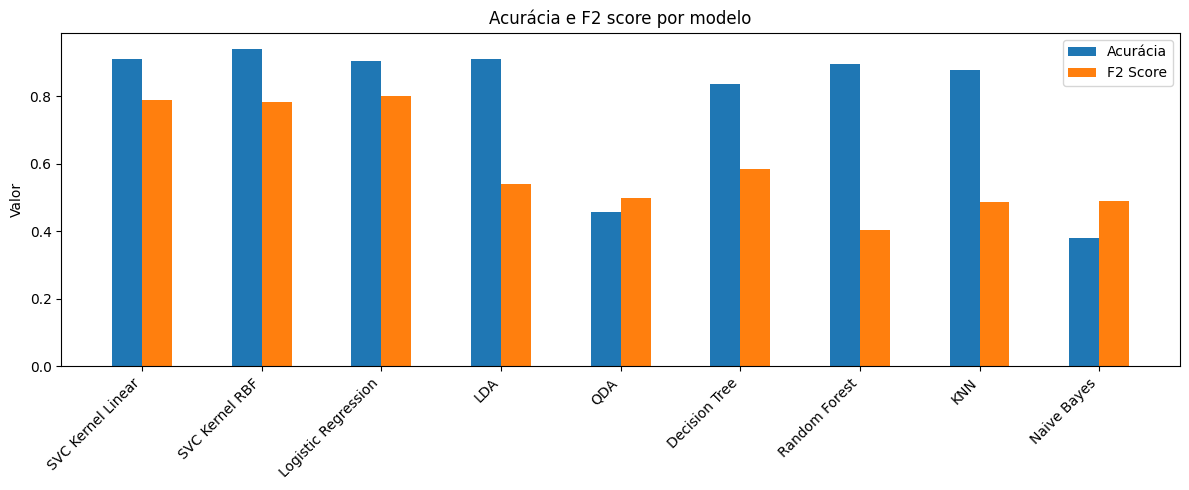

In [34]:
# Plotando os resultados
x = np.arange(len(resultados_df["Modelo"]))
width = 0.25 

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, resultados_df["Acurácia"], width, label="Acurácia")
plt.bar(x + width/2, resultados_df["F2 Score"], width, label="F2 Score")

plt.xticks(x, resultados_df["Modelo"], rotation=45, ha='right')
plt.ylabel("Valor")
plt.title("Acurácia e F2 score por modelo")
plt.legend()
plt.tight_layout()
plt.show()


## **5.TESTES ESPECIFICOS DOS MODELOS**
Após identificar quais modelos eram mais adequados ao problema, foi conduzida uma nova etapa de experimentação utilizando os dados sem filtragem de imagem, apenas a redução de dimensão pelo PCA.  O objetivo era entender o impacto das ferramentas do "scikit-image" no resultado do problema.

Os resultados mostraram que mesmo sem a filtragem, os modelos apresentaram otimos valores na métrica. Em comparação direta, os modelos treinados com dados pré-processados apresentaram melhor desempenho geral, ainda que a diferença entre as duas abordagens tenha sido pequena. A ligeira vantagem dos dados processados confirma que, embora os algoritmos escolhidos sejam robustos, o tratamento prévio das imagens melhora a qualidade das representações internas utilizadas pelos classificadores, contribuindo para previsões mais confiáveis.

In [54]:
# Svc Linear com imagens brutas
LinearSVC_CV.fit(feat, resp['Volcano?'])
CM_LinearSCV_raw = confusion_matrix(test_resp['Volcano?'], LinearSVC_CV.predict(test_feat))
ConfusionMatrixMetrics(CM_LinearSCV_raw).print()


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Matriz de confusão:
2064  236  
  79  355  


Prevalência: 0.159
Acurácia: 0.885


Taxa de falsos positivos: 0.103
Taxa de verdadeiros negativos (Especificidade): 0.897
Taxa de verdadeiros positivos (Recall): 0.818
Taxa de falsos negativos: 0.182


False omission rate: 0.037
Valor preditivo positivo (Precisão): 0.601
Valor preditivo negativo: 0.963
False discovery rate: 0.399


F1 Score: 0.693
F2 Score: 0.763


In [ ]:
# SVC com Kernel rbf com imagens brutas
SVC_rbf_CV.fit(feat, resp['Volcano?'])
CM_LinearSCV_raw = confusion_matrix(test_resp['Volcano?'], SVC_rbf_CV.predict(test_feat))
ConfusionMatrixMetrics(CM_LinearSCV_raw).print()


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Matriz de confusão:
2244   56  
 104  330  


Prevalência: 0.159
Acurácia: 0.941


Taxa de falsos positivos: 0.024
Taxa de verdadeiros negativos (Especificidade): 0.976
Taxa de verdadeiros positivos (Recall): 0.76
Taxa de falsos negativos: 0.24


False omission rate: 0.044
Valor preditivo positivo (Precisão): 0.855
Valor preditivo negativo: 0.956
False discovery rate: 0.145


F1 Score: 0.805
F2 Score: 0.778


In [53]:
# Logistic Regression Classifier com imagens brutas
LR_pipe_CV.fit(feat, resp['Volcano?'])
CM_LR_raw = confusion_matrix(test_resp['Volcano?'], LR_pipe_CV.predict(test_feat))
ConfusionMatrixMetrics(CM_LR_raw).print()

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\Leo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Matriz de confusão:
2057  243  
  67  367  


Prevalência: 0.159
Acurácia: 0.887


Taxa de falsos positivos: 0.106
Taxa de verdadeiros negativos (Especificidade): 0.894
Taxa de verdadeiros positivos (Recall): 0.846
Taxa de falsos negativos: 0.154


False omission rate: 0.032
Valor preditivo positivo (Precisão): 0.602
Valor preditivo negativo: 0.968
False discovery rate: 0.398


F1 Score: 0.703
F2 Score: 0.782


## **6.AJUSTANDO OS MODELOS**
Após a definição dos modelos considerados adequados para o problema, foi realizada uma etapa final de otimização focada no ajuste do limiar de decisão (threshold). Embora esses modelos retornem previsões probabilísticas ou scores contínuos, a conversão desses valores para classes discretas depende de um threshold, tradicionalmente fixado em 0.5. No entanto, para problemas com classes desbalanceadas e onde o objetivo principal é maximizar a detecção da classe positiva, esse valor padrão raramente é o ideal.

Assim, com o uso de uma função que busca maximizar a curva "precision-recall", e com o valor encontrado sendo aplicado limitar o modelo e assim produzir classificadores que detectam mais vezes a classe positiva sem compremeter a precisão do modelo. 

Entre os três modelos, o SVC com kernel RBF apresentou o melhor desempenho final, alcançando o maior F2-score (0.841), indicando uma excelente capacidade de detecção da classe positiva após o ajuste do limiar. Os modelos linear e logístico também apresentaram resultados otimizados, com F2-scores próximos a 0.80, demonstrando consistência e boa generalização.

In [35]:
# avaliar melhor threshold para F2
from sklearn.metrics import precision_recall_curve, fbeta_score
def best_f2_threshold(best_model):
    scores = best_model.decision_function(Pr_test)
    y_true = test_resp['Volcano?']

    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    best_t = None
    best_f2 = -1

    for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
        f2 = (1 + 2**2) * (p*r) / (2**2 * p + r + 1e-10)
        if f2 > best_f2:
            best_f2 = f2
            best_t = t

    print("Melhor threshold:", best_t)
    print("Melhor F2:", best_f2)
    return best_t

In [36]:
resultados_ajuste = {
    'Modelo': [],
    'Acurácia': [],
    'F2 Score': [],
}

def append_results2(nome, cm):
    cm_metrics = ConfusionMatrixMetrics(cm)
    resultados_ajuste["Modelo"].append(nome)
    resultados_ajuste["Acurácia"].append(np.round(cm_metrics.acc(), 3))
    resultados_ajuste["F2 Score"].append(np.round(cm_metrics.F2(), 3))

In [37]:
# Melhor Threshold para F2 - Linear SVC
best_f2_threshold(LinearSVC_CV)

Melhor threshold: -0.03667792409166992
Melhor F2: 0.7998251748022933


np.float64(-0.03667792409166992)

In [38]:
# Aplicar o melhor threshold encontrado - Linear SVC
p0 = best_f2_threshold(LinearSVC_CV)
scores = LinearSVC_CV.decision_function(Pr_test)
y_pred = (scores >= p0).astype(int)
CM_LinearSCV_tuned = confusion_matrix(test_resp['Volcano?'], y_pred)
ConfusionMatrixMetrics(CM_LinearSCV_tuned).print()
append_results2("SVC Kernel Linear", CM_LinearSCV_tuned)

Melhor threshold: -0.03667792409166992
Melhor F2: 0.7998251748022933
Matriz de confusão:
2114  186  
  68  366  


Prevalência: 0.159
Acurácia: 0.907


Taxa de falsos positivos: 0.081
Taxa de verdadeiros negativos (Especificidade): 0.919
Taxa de verdadeiros positivos (Recall): 0.843
Taxa de falsos negativos: 0.157


False omission rate: 0.031
Valor preditivo positivo (Precisão): 0.663
Valor preditivo negativo: 0.969
False discovery rate: 0.337


F1 Score: 0.742
F2 Score: 0.8


In [39]:
# Melhor Threshold para F2 - rbf SVC
best_f2_threshold(SVC_rbf_CV)

Melhor threshold: -0.9966070094427517
Melhor F2: 0.8408215660865189


np.float64(-0.9966070094427517)

In [40]:
# Aplicar o melhor threshold encontrado - rbf SVC
p0 = best_f2_threshold(SVC_rbf_CV)
scores = SVC_rbf_CV.decision_function(Pr_test)
y_pred = (scores >= p0).astype(int)
CM_RBFSVC_tuned = confusion_matrix(test_resp['Volcano?'], y_pred)
ConfusionMatrixMetrics(CM_RBFSVC_tuned).print()
append_results2("SVC Kernel RBF", CM_RBFSVC_tuned)

Melhor threshold: -0.9966070094427517
Melhor F2: 0.8408215660865189
Matriz de confusão:
2092  208  
  41  393  


Prevalência: 0.159
Acurácia: 0.909


Taxa de falsos positivos: 0.09
Taxa de verdadeiros negativos (Especificidade): 0.91
Taxa de verdadeiros positivos (Recall): 0.906
Taxa de falsos negativos: 0.094


False omission rate: 0.019
Valor preditivo positivo (Precisão): 0.654
Valor preditivo negativo: 0.981
False discovery rate: 0.346


F1 Score: 0.759
F2 Score: 0.841


In [41]:
# Melhor Threshold para F2 - LogReg
best_f2_threshold(LR_pipe_CV)

Melhor threshold: -0.08480394
Melhor F2: 0.8045729076555288


np.float32(-0.08480394)

In [42]:
# Aplicar o melhor threshold encontrado - LogReg
p0 =  best_f2_threshold(LR_pipe_CV)
scores = LR_pipe_CV.decision_function(Pr_test)
y_pred = (scores >= p0).astype(int)
CM_LR_tuned = confusion_matrix(test_resp['Volcano?'], y_pred)
ConfusionMatrixMetrics(CM_LR_tuned).print()
append_results2("Logistic Regression", CM_LR_tuned)

Melhor threshold: -0.08480394
Melhor F2: 0.8045729076555288
Matriz de confusão:
2091  209  
  61  373  


Prevalência: 0.159
Acurácia: 0.901


Taxa de falsos positivos: 0.091
Taxa de verdadeiros negativos (Especificidade): 0.909
Taxa de verdadeiros positivos (Recall): 0.859
Taxa de falsos negativos: 0.141


False omission rate: 0.028
Valor preditivo positivo (Precisão): 0.641
Valor preditivo negativo: 0.972
False discovery rate: 0.359


F1 Score: 0.734
F2 Score: 0.805


In [43]:
resultados_ajuste_df = pd.DataFrame(resultados_ajuste)
print(resultados_ajuste_df)

                Modelo  Acurácia  F2 Score
0    SVC Kernel Linear     0.907     0.800
1       SVC Kernel RBF     0.909     0.841
2  Logistic Regression     0.901     0.805


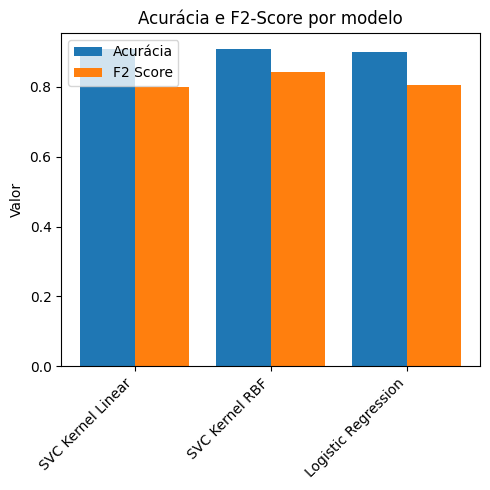

In [44]:
# Plotando os resultados
x = np.arange(len(resultados_ajuste_df["Modelo"]))
width = 0.4

plt.figure(figsize=(5, 5))
plt.bar(x - width/2, resultados_ajuste_df["Acurácia"], width, label="Acurácia")
plt.bar(x + width/2, resultados_ajuste_df["F2 Score"], width, label="F2 Score")

plt.xticks(x, resultados_ajuste_df["Modelo"], rotation=45, ha='right')
plt.ylabel("Valor")
plt.title("Acurácia e F2-Score por modelo")
plt.legend()
plt.tight_layout()
plt.show()

## **7.CONCLUSÃO**
Ao longo deste trabalho foram conduzidas diversas etapas de investigação, incluindo análise exploratória, experimentos de pré-processamento, redução de dimensionalidade, aplicação de múltiplos classificadores e otimização de hiperparâmetros. Com base nessas análises, ficou evidente que o problema de detecção de vulcões em imagens de satélite exige modelos capazes de lidar com dados de alta dimensionalidade e classes desbalanceadas.

Após avaliar todos os modelos testados, três se mostraram adequados ao problema: SVC com kernel linear, SVC com kernel RBF e Regressão Logística.Esses modelos apresentaram desempenho consistente e a metrica de escolha (F2-score) elevado. 

O **SVC com kernel RBF** apresentou o melhor desempenho global, alcançando F2-score de 0.841, o maior entre todos os modelos avaliados, além de uma acurácia elevada (0.909). Esse resultado indica que o modelo é particularmente eficaz em identificar corretamente as imagens com vulcões, atendendo ao objetivo principal do projeto. Sua capacidade de modelar relações não lineares mostrou-se vantajosa diante das características complexas das imagens, mesmo após o pré-processamento e a redução de dimensionalidade, o tornando o modelo de escolha quanto a resolução do problema. 
